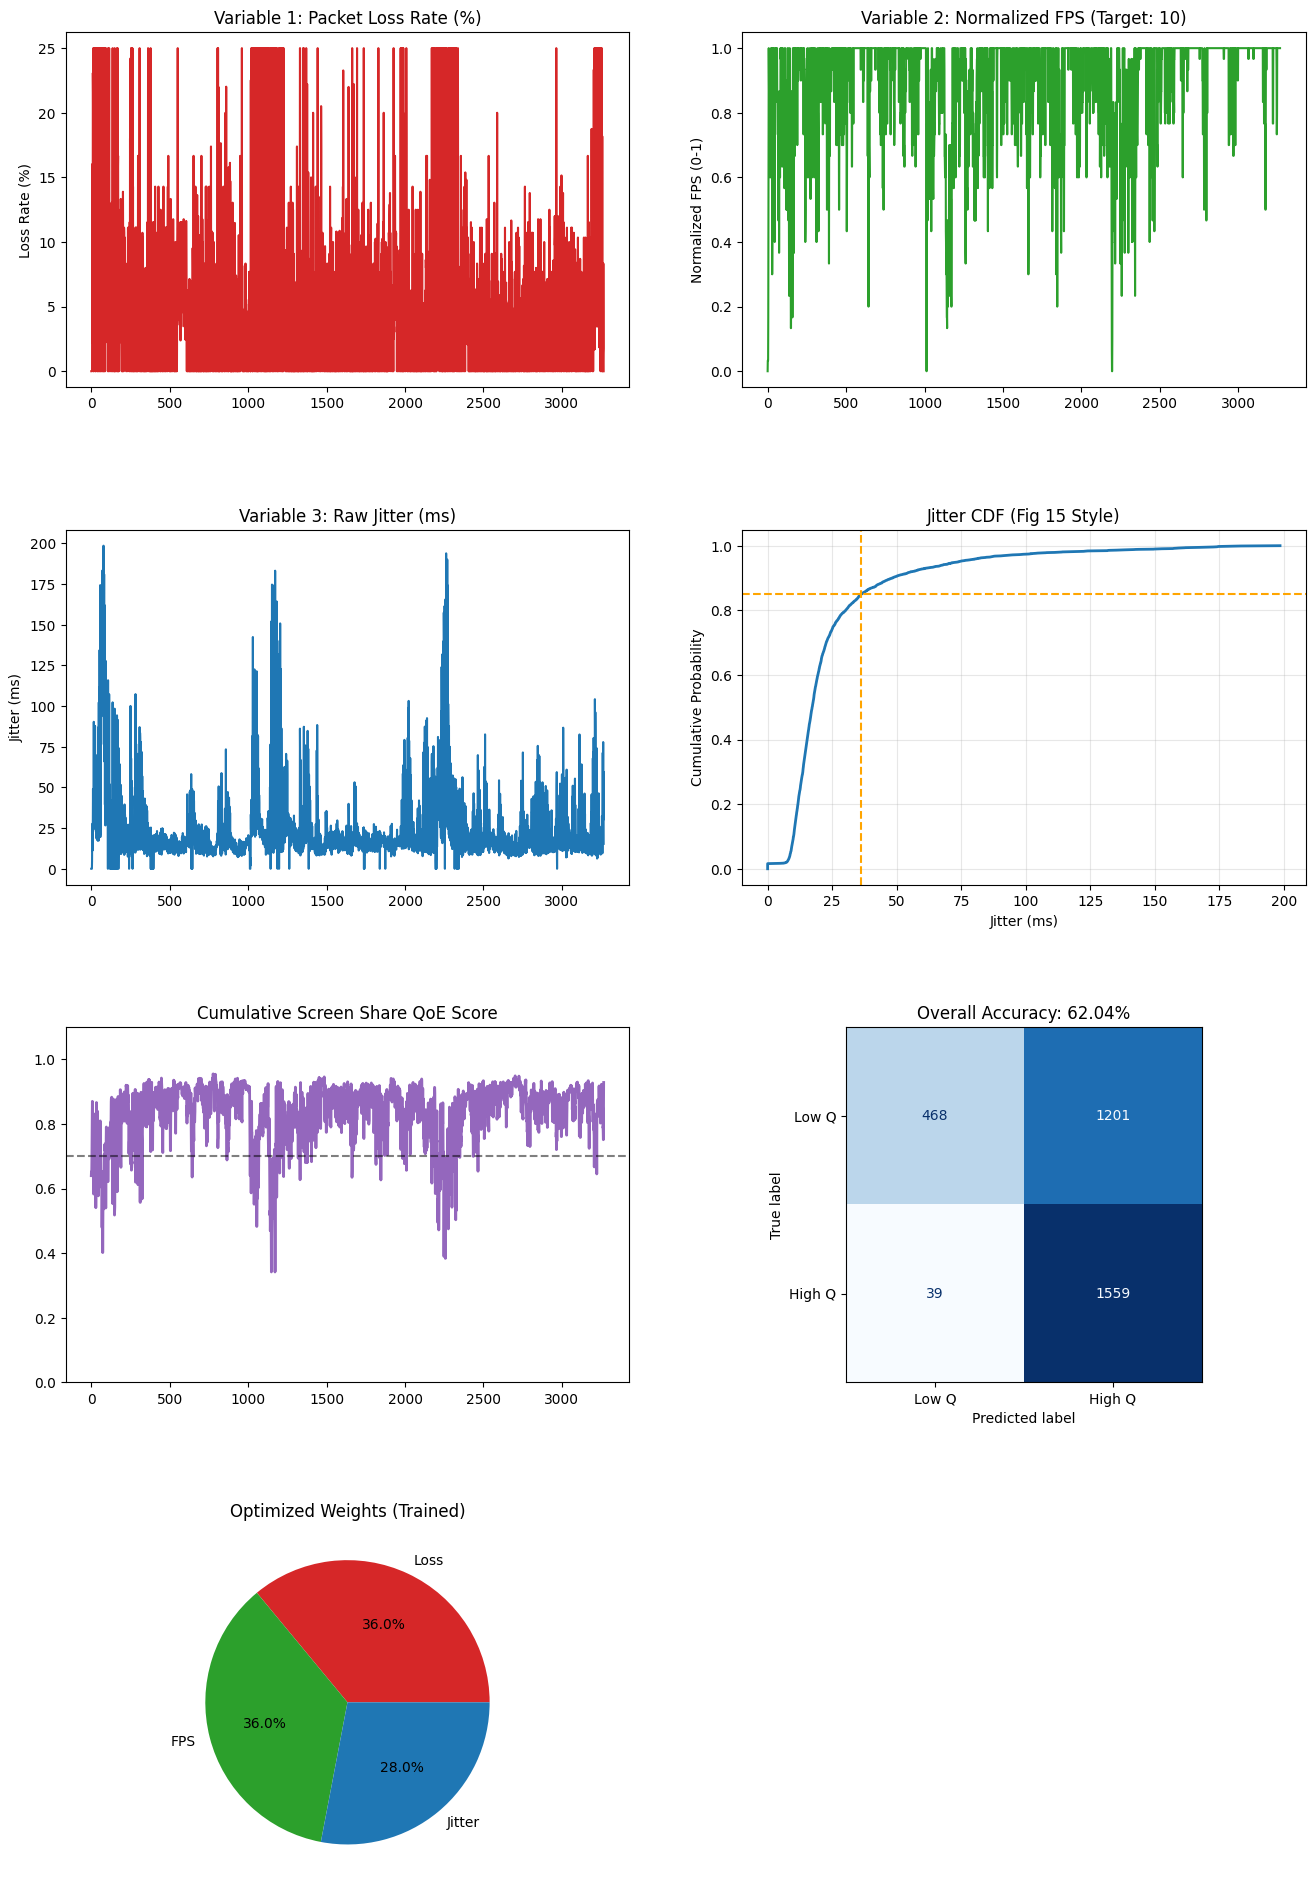

              precision    recall  f1-score   support

           0       0.92      0.28      0.43      1669
           1       0.56      0.98      0.72      1598

    accuracy                           0.62      3267
   macro avg       0.74      0.63      0.57      3267
weighted avg       0.75      0.62      0.57      3267


EXPERIMENT STATISTICS
Experiment      | D1 Loss    | D2 Loss    | D3 Loss    | Avg. Loss  | Avg. FPS   | Avg. Jitter (ms) | Optimal Weights      | Accuracy   | Avg. QoE Score
-------------------------------------------------------------------------------------------------------------------------------------------------
Zoom QoE        | 0.0593     | 0.0595     | 0.0558     | 0.0582     | 17.95      | 25.08            | (0.36, 0.36, 0.28)   | 62.04%     | 0.8310      


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from itertools import product

def remove_loss_outliers(df, method='iqr', threshold=1.5):
    """
    Remove or cap packet loss outliers.
    """
    if method == 'iqr':
        Q1 = df['loss_rate'].quantile(0.25)
        Q3 = df['loss_rate'].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + threshold * IQR
        
        outlier_count = (df['loss_rate'] > upper_bound).sum()
        df_clean = df[df['loss_rate'] <= upper_bound].copy()
        
    elif method == 'cap':
        percentile = 100 - threshold
        cap_value = df['loss_rate'].quantile(percentile / 100)
        outlier_count = (df['loss_rate'] > cap_value).sum()
        df_clean = df.copy()
        df_clean['loss_rate'] = df_clean['loss_rate'].clip(upper=cap_value)
    
    return df_clean, outlier_count

# ==========================================
# CONFIGURATION
# ==========================================
MANUAL_SCREENSHARE_MODE = False
PARENT_FOLDER = "." 

LOSS_THRESHOLD = 0.05
FPS_MIN = 5
QOE_PASS_SCORE = 0.7 
# ==========================================

def load_data_from_folders(parent_path):
    all_frames = []
    for root, dirs, files in os.walk(parent_path):
        for file in files:
            if file.lower().endswith(".csv") and "stats" in file.lower():
                file_path = os.path.join(root, file)
                try:
                    temp_df = pd.read_csv(file_path)
                    temp_df.columns = [c.lower() for c in temp_df.columns]
                    temp_df = temp_df.sort_values(by='ts_s').reset_index(drop=True)
                    temp_df['trial_source'] = os.path.basename(root)
                    all_frames.append(temp_df)
                except Exception as e:
                    print(f"Skipping {file}: {e}")
    
    df = pd.concat(all_frames).reset_index(drop=True)
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)
    return df

def calculate_metrics(df, is_screenshare):
    df["loss_rate"] = (df["lost"] / (df["pkts"] + df["lost"] + 1e-10)).clip(0, 1)
    fps_target = 10 if is_screenshare else 30
    jitter_threshold = 60 if is_screenshare else 40
    
    df['fps_norm'] = (df['frames'] / fps_target).clip(0, 1)
    df['jitter_ms'] = df['mean_jitter'].clip(0, 500)
    df['jitter_norm'] = (1 - (df['jitter_ms'] / jitter_threshold)).clip(0, 1)
    
    df['actual_qoe_bin'] = np.where((df['loss_rate'] > LOSS_THRESHOLD) | (df['frames'] < FPS_MIN), 0, 1)
    return df, fps_target, jitter_threshold

def train_best_weights(df):
    best_acc = 0
    best_w = (0.4, 0.3, 0.3)
    weights_range = [np.round(x, 2) for x in np.linspace(0.1, 0.8, 20)]

    for w1, w2 in product(weights_range, weights_range):
        w3 = np.round(1.0 - w1 - w2, 2)
        if w3 >= 0.05:
            score = (w1 * (1 - df['loss_rate'])) + (w2 * df['fps_norm']) + (w3 * df['jitter_norm'])
            pred_bin = np.where(score > QOE_PASS_SCORE, 1, 0)
            acc = (pred_bin == df['actual_qoe_bin']).mean()
            if acc > best_acc:
                best_acc = acc
                best_w = (w1, w2, w3)
    return best_w, best_acc

# EXECUTION
try:
    df = load_data_from_folders(PARENT_FOLDER)
    df, fps_t, j_thresh = calculate_metrics(df, MANUAL_SCREENSHARE_MODE)
    df, _ = remove_loss_outliers(df, method='cap', threshold=5.0)
    df['actual_qoe_bin'] = np.where((df['loss_rate'] > LOSS_THRESHOLD) | (df['frames'] < FPS_MIN), 0, 1)
    best_weights, max_acc = train_best_weights(df)

    w1, w2, w3 = best_weights
    df['qoe_score'] = (w1 * (1 - df['loss_rate'])) + (w2 * df['fps_norm']) + (w3 * df['jitter_norm'])
    df['qoe_smooth'] = df['qoe_score'].rolling(window=3, center=True).mean().fillna(df['qoe_score'])
    y_pred = np.where(df['qoe_score'] > QOE_PASS_SCORE, 1, 0)

    # UPDATED PLOTTING: 4x2 Grid to include Jitter CDF
    fig, axes = plt.subplots(4, 2, figsize=(16, 24))
    plt.subplots_adjust(hspace=0.4)
    mode_str = "Screen Share" if MANUAL_SCREENSHARE_MODE else "Standard Video"

    # [0,0] Loss
    axes[0, 0].plot(df['loss_rate']*100, color='#d62728')
    axes[0, 0].set_title('Variable 1: Packet Loss Rate (%)')
    axes[0, 0].set_ylabel('Loss Rate (%)')

    # [0,1] FPS
    fps_smooth = df['fps_norm'].rolling(window=3, center=True).mean().fillna(df['fps_norm'])
    axes[0, 1].plot(fps_smooth, color='#2ca02c')
    axes[0, 1].set_title(f'Variable 2: Normalized FPS (Target: {fps_t})')
    axes[0, 1].set_ylabel('Normalized FPS (0-1)')

    # [1,0] Jitter Time Series
    axes[1, 0].plot(df['jitter_ms'], color='#1f77b4')
    axes[1, 0].set_title(f'Variable 3: Raw Jitter (ms)')
    axes[1, 0].set_ylabel('Jitter (ms)')

    # [1,1] NEW: Jitter CDF (Cumulative Distribution Function)
    sorted_jitter = np.sort(df['jitter_ms'])
    yvals = np.arange(len(sorted_jitter)) / float(len(sorted_jitter)-1)
    axes[1, 1].plot(sorted_jitter, yvals, color='#1f77b4', linewidth=2)
    axes[1, 1].set_title('Jitter CDF (Fig 15 Style)')
    axes[1, 1].set_xlabel('Jitter (ms)')
    axes[1, 1].set_ylabel('Cumulative Probability')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Calculate 85th percentile (to check the 15% exceeding 200ms claim)
    p85 = np.percentile(df['jitter_ms'], 85)
    axes[1, 1].axhline(0.85, color='orange', linestyle='--', label='85th Percentile')
    axes[1, 1].axvline(p85, color='orange', linestyle='--')

    # [2,0] Cumulative QoE
    axes[2, 0].plot(df['qoe_smooth'], color='#9467bd', linewidth=2)
    axes[2, 0].axhline(QOE_PASS_SCORE, color='black', linestyle='--', alpha=0.5)
    axes[2, 0].set_title(f'Cumulative {mode_str} QoE Score')
    axes[2, 0].set_ylim(0, 1.1)

    # [2,1] Confusion Matrix
    cm = confusion_matrix(df['actual_qoe_bin'], y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Q', 'High Q'])
    disp.plot(ax=axes[2, 1], cmap='Blues', colorbar=False)
    axes[2, 1].set_title(f'Overall Accuracy: {max_acc:.2%}')

    # [3,0] Weights Pie
    axes[3, 0].pie(best_weights, labels=['Loss', 'FPS', 'Jitter'], autopct='%1.1f%%', colors=['#d62728', '#2ca02c', '#1f77b4'])
    axes[3, 0].set_title('Optimized Weights (Trained)')

    # [3,1] Blank for layout
    axes[3, 1].axis('off')

    # Save the figure
    output_path = os.path.join(PARENT_FOLDER, 'qoe_analysis_plots.png')
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"Plots saved to: {output_path}")
    
    plt.show()
    print(classification_report(df['actual_qoe_bin'], y_pred))
  
    print("\n" + "="*120)
    print("EXPERIMENT STATISTICS")
    print("="*120)
    
    # Calculate per-trial stats
    trials = sorted(df['trial_source'].unique())
    trial_losses = [df[df['trial_source'] == t]['loss_rate'].mean() for t in trials]
    trial_fps = [df[df['trial_source'] == t]['frames'].mean() for t in trials]
    trial_jitter = [df[df['trial_source'] == t]['jitter_ms'].mean() for t in trials]
    
    # Format output
    print(f"{'Experiment':<15} | {'D1 Loss':<10} | {'D2 Loss':<10} | {'D3 Loss':<10} | {'Avg. Loss':<10} | {'Avg. FPS':<10} | {'Avg. Jitter (ms)':<16} | {'Optimal Weights':<20} | {'Accuracy':<10}")
    print("-" * 130)
    
    experiment_name = "Zoom QoE"
    avg_loss = df['loss_rate'].mean()
    avg_fps = df['frames'].mean()
    avg_jitter = df['jitter_ms'].mean()
    weights_str = f"({w1:.2f}, {w2:.2f}, {w3:.2f})"
    
    print(f"{experiment_name:<15} | {trial_losses[0]:<10.4f} | {trial_losses[1]:<10.4f} | {trial_losses[2]:<10.4f} | {avg_loss:<10.4f} | {avg_fps:<10.2f} | {avg_jitter:<16.2f} | {weights_str:<20} | {max_acc:<10.2%}")
    print("="*130)

except Exception as e:
    print(f"Error: {e}")

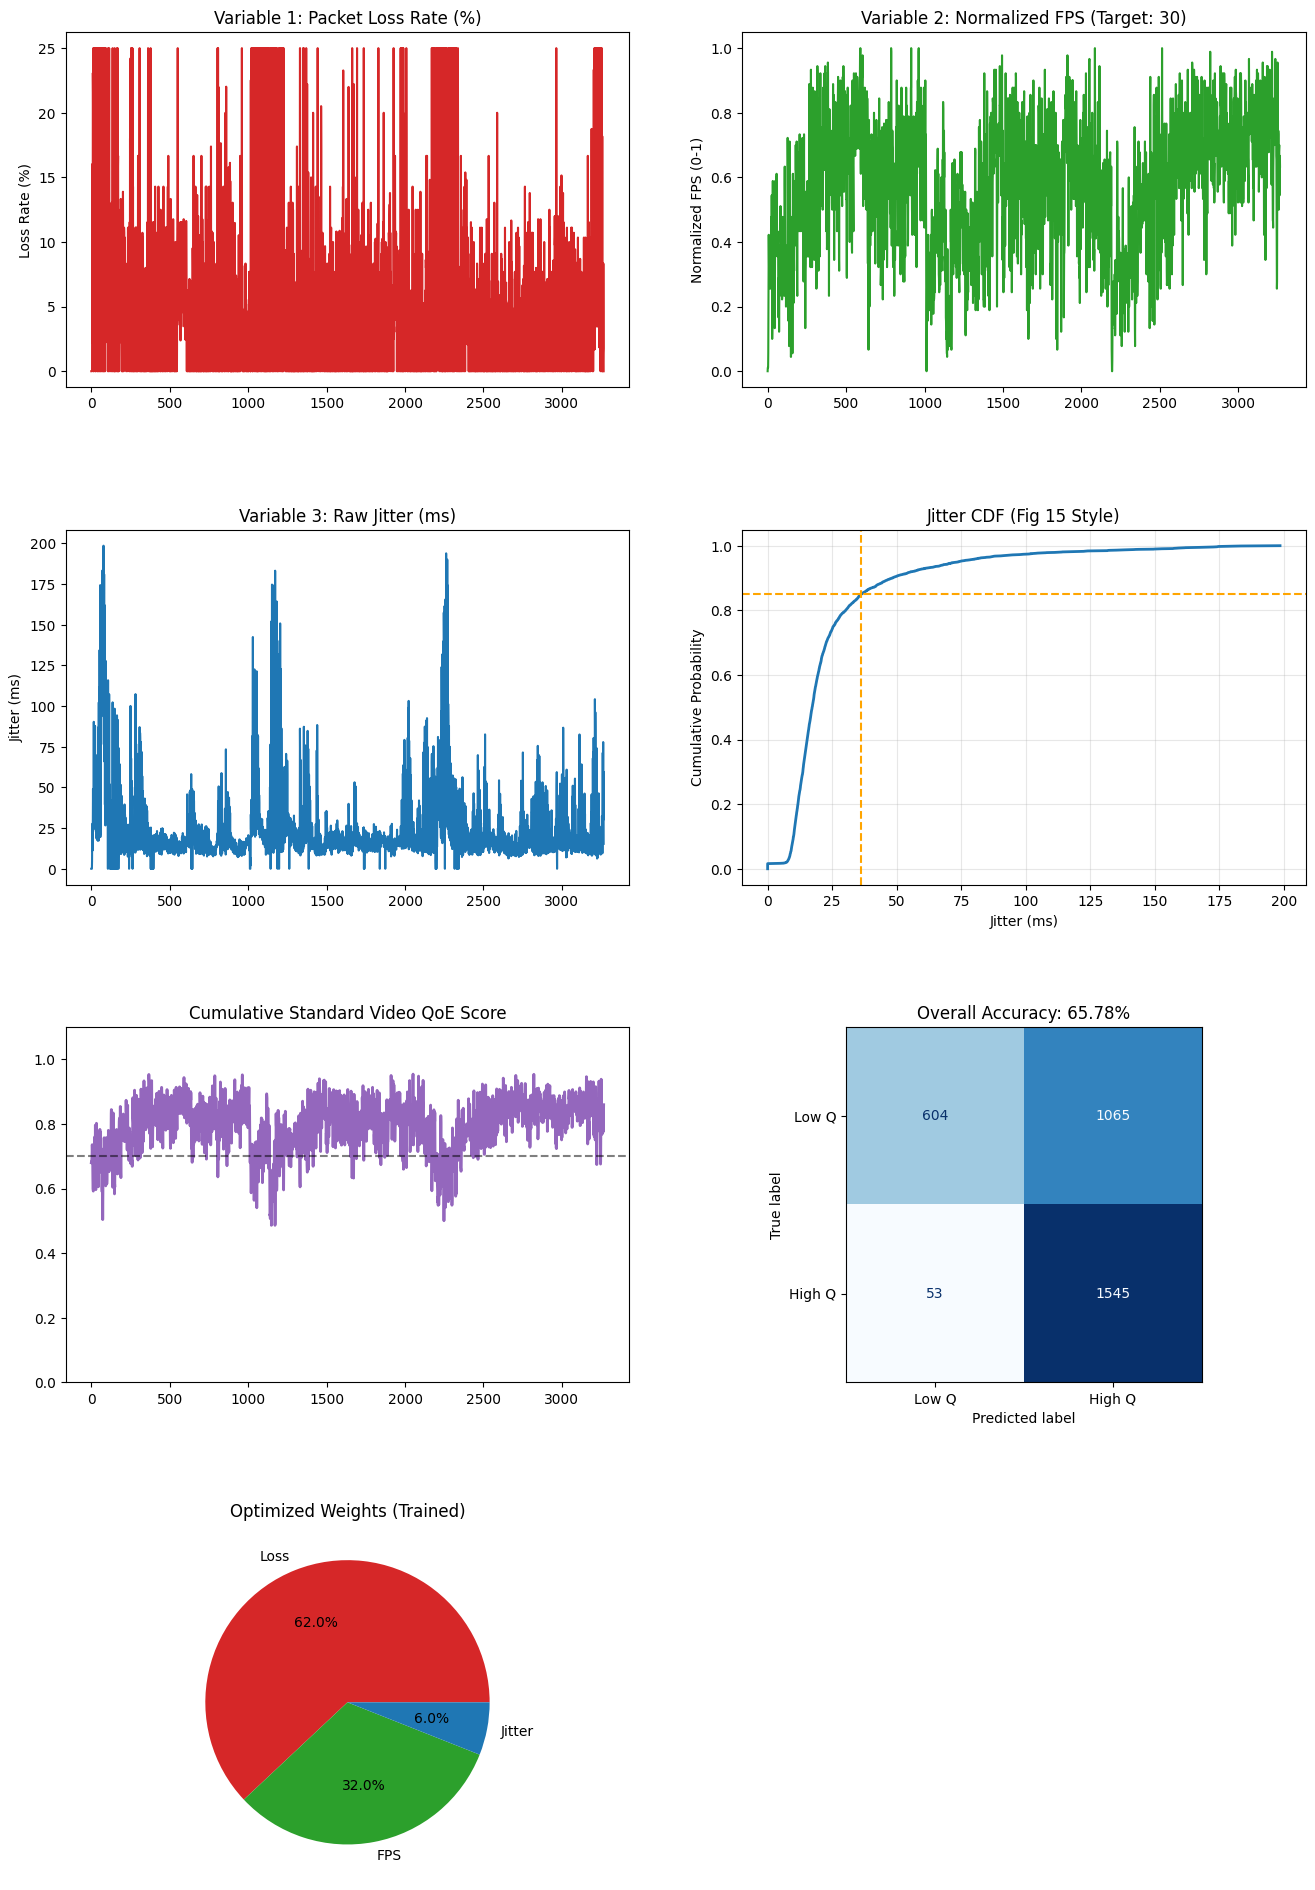

              precision    recall  f1-score   support

           0       0.92      0.36      0.52      1669
           1       0.59      0.97      0.73      1598

    accuracy                           0.66      3267
   macro avg       0.76      0.66      0.63      3267
weighted avg       0.76      0.66      0.62      3267


EXPERIMENT STATISTICS
Experiment      | D1 Loss    | D2 Loss    | D3 Loss    | Avg. Loss  | Avg. FPS   | Avg. Jitter (ms) | Optimal Weights      | Accuracy   | Avg. QoE Score
-------------------------------------------------------------------------------------------------------------------------------------------------
Zoom QoE        | 0.0593     | 0.0595     | 0.0558     | 0.0582     | 17.95      | 25.08            | (0.62, 0.32, 0.06)   | 65.78%     | 0.7962      


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from itertools import product

def remove_loss_outliers(df, method='iqr', threshold=1.5):
    """
    Remove or cap packet loss outliers.
    """
    if method == 'iqr':
        Q1 = df['loss_rate'].quantile(0.25)
        Q3 = df['loss_rate'].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + threshold * IQR
        
        outlier_count = (df['loss_rate'] > upper_bound).sum()
        df_clean = df[df['loss_rate'] <= upper_bound].copy()
        
    elif method == 'cap':
        percentile = 100 - threshold
        cap_value = df['loss_rate'].quantile(percentile / 100)
        outlier_count = (df['loss_rate'] > cap_value).sum()
        df_clean = df.copy()
        df_clean['loss_rate'] = df_clean['loss_rate'].clip(upper=cap_value)
    
    return df_clean, outlier_count

# ==========================================
# CONFIGURATION
# ==========================================
MANUAL_SCREENSHARE_MODE = False
PARENT_FOLDER = "." 

LOSS_THRESHOLD = 0.05
FPS_MIN = 5
QOE_PASS_SCORE = 0.7 
# ==========================================

def load_data_from_folders(parent_path):
    all_frames = []
    for root, dirs, files in os.walk(parent_path):
        for file in files:
            if file.lower().endswith(".csv") and "stats" in file.lower():
                file_path = os.path.join(root, file)
                try:
                    temp_df = pd.read_csv(file_path)
                    temp_df.columns = [c.lower() for c in temp_df.columns]
                    temp_df = temp_df.sort_values(by='ts_s').reset_index(drop=True)
                    temp_df['trial_source'] = os.path.basename(root)
                    all_frames.append(temp_df)
                except Exception as e:
                    print(f"Skipping {file}: {e}")
    
    df = pd.concat(all_frames).reset_index(drop=True)
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)
    return df

def calculate_metrics(df, is_screenshare):
    df["loss_rate"] = (df["lost"] / (df["pkts"] + df["lost"] + 1e-10)).clip(0, 1)
    fps_target = 10 if is_screenshare else 30
    jitter_threshold = 60 if is_screenshare else 40
    
    df['fps_norm'] = (df['frames'] / fps_target).clip(0, 1)
    df['jitter_ms'] = df['mean_jitter'].clip(0, 500)
    df['jitter_norm'] = (1 - (df['jitter_ms'] / jitter_threshold)).clip(0, 1)
    
    df['actual_qoe_bin'] = np.where((df['loss_rate'] > LOSS_THRESHOLD) | (df['frames'] < FPS_MIN), 0, 1)
    return df, fps_target, jitter_threshold

def train_best_weights(df):
    best_acc = 0
    best_w = (0.4, 0.3, 0.3)
    weights_range = [np.round(x, 2) for x in np.linspace(0.1, 0.8, 20)]

    for w1, w2 in product(weights_range, weights_range):
        w3 = np.round(1.0 - w1 - w2, 2)
        if w3 >= 0.05:
            score = (w1 * (1 - df['loss_rate'])) + (w2 * df['fps_norm']) + (w3 * df['jitter_norm'])
            pred_bin = np.where(score > QOE_PASS_SCORE, 1, 0)
            acc = (pred_bin == df['actual_qoe_bin']).mean()
            if acc > best_acc:
                best_acc = acc
                best_w = (w1, w2, w3)
    return best_w, best_acc

# EXECUTION
try:
    df = load_data_from_folders(PARENT_FOLDER)
    df, fps_t, j_thresh = calculate_metrics(df, MANUAL_SCREENSHARE_MODE)
    df, _ = remove_loss_outliers(df, method='cap', threshold=5.0)
    df['actual_qoe_bin'] = np.where((df['loss_rate'] > LOSS_THRESHOLD) | (df['frames'] < FPS_MIN), 0, 1)
    best_weights, max_acc = train_best_weights(df)

    w1, w2, w3 = best_weights
    df['qoe_score'] = (w1 * (1 - df['loss_rate'])) + (w2 * df['fps_norm']) + (w3 * df['jitter_norm'])
    df['qoe_smooth'] = df['qoe_score'].rolling(window=3, center=True).mean().fillna(df['qoe_score'])
    y_pred = np.where(df['qoe_score'] > QOE_PASS_SCORE, 1, 0)

    # UPDATED PLOTTING: 4x2 Grid to include Jitter CDF
    fig, axes = plt.subplots(4, 2, figsize=(16, 24))
    plt.subplots_adjust(hspace=0.4)
    mode_str = "Screen Share" if MANUAL_SCREENSHARE_MODE else "Standard Video"

    # [0,0] Loss
    axes[0, 0].plot(df['loss_rate']*100, color='#d62728')
    axes[0, 0].set_title('Variable 1: Packet Loss Rate (%)')
    axes[0, 0].set_ylabel('Loss Rate (%)')

    # [0,1] FPS
    fps_smooth = df['fps_norm'].rolling(window=3, center=True).mean().fillna(df['fps_norm'])
    axes[0, 1].plot(fps_smooth, color='#2ca02c')
    axes[0, 1].set_title(f'Variable 2: Normalized FPS (Target: {fps_t})')
    axes[0, 1].set_ylabel('Normalized FPS (0-1)')

    # [1,0] Jitter Time Series
    axes[1, 0].plot(df['jitter_ms'], color='#1f77b4')
    axes[1, 0].set_title(f'Variable 3: Raw Jitter (ms)')
    axes[1, 0].set_ylabel('Jitter (ms)')

    # [1,1] NEW: Jitter CDF (Cumulative Distribution Function)
    sorted_jitter = np.sort(df['jitter_ms'])
    yvals = np.arange(len(sorted_jitter)) / float(len(sorted_jitter)-1)
    axes[1, 1].plot(sorted_jitter, yvals, color='#1f77b4', linewidth=2)
    axes[1, 1].set_title('Jitter CDF (Fig 15 Style)')
    axes[1, 1].set_xlabel('Jitter (ms)')
    axes[1, 1].set_ylabel('Cumulative Probability')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Calculate 85th percentile (to check the 15% exceeding 200ms claim)
    p85 = np.percentile(df['jitter_ms'], 85)
    axes[1, 1].axhline(0.85, color='orange', linestyle='--', label='85th Percentile')
    axes[1, 1].axvline(p85, color='orange', linestyle='--')

    # [2,0] Cumulative QoE
    axes[2, 0].plot(df['qoe_smooth'], color='#9467bd', linewidth=2)
    axes[2, 0].axhline(QOE_PASS_SCORE, color='black', linestyle='--', alpha=0.5)
    axes[2, 0].set_title(f'Cumulative {mode_str} QoE Score')
    axes[2, 0].set_ylim(0, 1.1)

    # [2,1] Confusion Matrix
    cm = confusion_matrix(df['actual_qoe_bin'], y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Q', 'High Q'])
    disp.plot(ax=axes[2, 1], cmap='Blues', colorbar=False)
    axes[2, 1].set_title(f'Overall Accuracy: {max_acc:.2%}')

    # [3,0] Weights Pie
    axes[3, 0].pie(best_weights, labels=['Loss', 'FPS', 'Jitter'], autopct='%1.1f%%', colors=['#d62728', '#2ca02c', '#1f77b4'])
    axes[3, 0].set_title('Optimized Weights (Trained)')

    # [3,1] Blank for layout
    axes[3, 1].axis('off')

    plt.show()
    print(classification_report(df['actual_qoe_bin'], y_pred))
  
    print("\n" + "="*120)
    print("EXPERIMENT STATISTICS")
    print("="*120)
    
    # Calculate per-trial stats
    trials = sorted(df['trial_source'].unique())
    trial_losses = [df[df['trial_source'] == t]['loss_rate'].mean() for t in trials]
    trial_fps = [df[df['trial_source'] == t]['frames'].mean() for t in trials]
    trial_jitter = [df[df['trial_source'] == t]['jitter_ms'].mean() for t in trials]
    
    # Format output
    print(f"{'Experiment':<15} | {'D1 Loss':<10} | {'D2 Loss':<10} | {'D3 Loss':<10} | {'Avg. Loss':<10} | {'Avg. FPS':<10} | {'Avg. Jitter (ms)':<16} | {'Optimal Weights':<20} | {'Accuracy':<10} | {'Avg. QoE Score':<12}")
    print("-" * 145)
    
    experiment_name = "Zoom QoE"
    avg_loss = df['loss_rate'].mean()
    avg_fps = df['frames'].mean()
    avg_jitter = df['jitter_ms'].mean()
    avg_qoe_score = df['qoe_score'].mean()
    weights_str = f"({w1:.2f}, {w2:.2f}, {w3:.2f})"
    
    print(f"{experiment_name:<15} | {trial_losses[0]:<10.4f} | {trial_losses[1]:<10.4f} | {trial_losses[2]:<10.4f} | {avg_loss:<10.4f} | {avg_fps:<10.2f} | {avg_jitter:<16.2f} | {weights_str:<20} | {max_acc:<10.2%} | {avg_qoe_score:<12.4f}")
    print("="*145)

except Exception as e:
    print(f"Error: {e}")